# Collecting thoughts of parents through BeautifulSoup

In [1]:
import requests

In [2]:
from bs4 import BeautifulSoup

In [3]:
r = requests.get('https://gn.cambridgeschool.edu.in/parentsfeedback/')

In [4]:
r.status_code

200

In [5]:
r.text

'<!DOCTYPE html><html lang=en-GB class=no-js><head><meta charset="UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=edge"><meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=1.0, user-scalable=no"><link rel=profile href=http://gmpg.org/xfn/11><link rel=pingback href=https://gn.cambridgeschool.edu.in/xmlrpc.php><link rel="shortcut icon" href=https://gn.cambridgeschool.edu.in/wp-content/themes/cs_branch/assets/img/favicon.ico><meta name="geo" content="IN-UP"><meta name="geo.placename" content="Greater Noida"><meta name="geo.position" content="28.47786861370444,77.49955549836157"><meta name="ICBM" content="28.47786861370444,77.49955549836157"><title>Parents Feedback - Cambridge School Greater Noida</title><meta name="description" content="Cambridge school takes parents feedback very seriously. We encourage every parent to come forward and provide their feedback on the functioning of the school and how we could make it better."><meta name="robots" conten

In [6]:
soup = BeautifulSoup(r.text, 'html.parser')

In [7]:
divs = soup.findAll(class_='wpb_wrapper')

In [8]:
thoughts = []
for div in divs:
    if div.find('em') != None:
        thoughts.append(div.find('em').text)

In [11]:
thoughts

['I want to thank all the teachers of Cambridge School Greater Noida, for the hard work they have put in for the online sessions, explaining everything in a detailed manner each day.\xa0Even the assignments are easy to understand for the children. A big thank you to all of them. ',
 'I want to thank all the teachers of Cambridge School Greater Noida, for the hard work they have put in for the online sessions, explaining everything in a detailed manner each day.\xa0Even the assignments are easy to understand for the children. A big thank you to all of them. ',
 'I would like to take this opportunity to thank all the teachers for the efforts they are putting together to teach our children. Preparing lessons, making kids learn through fun, all this through distance learning. ',
 'I would like to take this opportunity to thank all the teachers for the efforts they are putting together to teach our children. Preparing lessons, making kids learn through fun, all this through distance learnin

# Analysing The Data

In [12]:
# importing required libraries
import pandas as pd
import numpy as np

In [13]:
df = pd.DataFrame(np.array(thoughts), columns =['thought'])

In [14]:
df.head()

,thought
0,I want to thank all the teachers of Cambridge ...
1,I want to thank all the teachers of Cambridge ...
2,I would like to take this opportunity to thank...
3,I would like to take this opportunity to thank...
4,We thank all the teachers for putting such ...


In [15]:
len(df.thought)

14

In [16]:
# length of words in each thought
df['word_count'] = df['thought'].apply(lambda x: len(x.split()))

In [17]:
df.head()

,thought,word_count
0,I want to thank all the teachers of Cambridge ...,50
1,I want to thank all the teachers of Cambridge ...,50
2,I would like to take this opportunity to thank...,35
3,I would like to take this opportunity to thank...,35
4,We thank all the teachers for putting such ...,68


In [18]:
# length of characters in each thought
df['char_count'] = df['thought'].apply(lambda x: len(x))

In [19]:
df.head()

,thought,word_count,char_count
0,I want to thank all the teachers of Cambridge ...,50,275
1,I want to thank all the teachers of Cambridge ...,50,275
2,I would like to take this opportunity to thank...,35,215
3,I would like to take this opportunity to thank...,35,215
4,We thank all the teachers for putting such ...,68,409


In [20]:
# average lenght of each words in the thoughts
def average_words(x):
    words = x.split()
    return sum(len(word) for word in words) / len(words)

In [21]:
df['average_word_length'] = df['thought'].apply(lambda x: average_words(x))

In [22]:
df.head()

,thought,word_count,char_count,average_word_length
0,I want to thank all the teachers of Cambridge ...,50,275,4.500000
1,I want to thank all the teachers of Cambridge ...,50,275,4.500000
2,I would like to take this opportunity to thank...,35,215,5.142857
3,I would like to take this opportunity to thank...,35,215,5.142857
4,We thank all the teachers for putting such ...,68,409,4.985294


# Data Cleaning 

In [23]:
# removing the punctuation
df['punctuation'] = df['thought'].str.replace('[^\w\s]', " ") # those who are not word and a white space replace it with nothing

<ipython-input-23-082243499053>:2: FutureWarning: The default value of regex will change from True to False in a future version.
  df['punctuation'] = df['thought'].str.replace('[^\w\s]', " ") # those who are not word and a white space replace it with nothing


In [24]:
df['punctuation']

0     I want to thank all the teachers of Cambridge ...
1     I want to thank all the teachers of Cambridge ...
2     I would like to take this opportunity to thank...
3     I would like to take this opportunity to thank...
4     We  thank all the teachers  for putting such  ...
5     We  thank all the teachers  for putting such  ...
6     I would like to express my appreciation toward...
7     I would like to express my appreciation toward...
8     Hi  I would like to say a big thank you to eac...
9     Hi  I would like to say a big thank you to eac...
10    We are new to Cambridge school and so far we a...
11    We are new to Cambridge school and so far we a...
12    Though these online classes were  unplanned an...
13    Though these online classes were  unplanned an...
Name: punctuation, dtype: object

In [25]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop = set(stopwords.words("english"))
# remove stopwords 
def remove_stopwords(thought):
    filtered_words = [word.lower() for word in thought.split() if word.lower() not in stop]
    return " ".join(filtered_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
df["stopword"] = df.thought.map(remove_stopwords)
df.head()

,thought,word_count,char_count,average_word_length,punctuation,stopword
0,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...
1,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...
2,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...
3,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...
4,We thank all the teachers for putting such ...,68,409,4.985294,We thank all the teachers for putting such ...,thank teachers putting immense effort online s...


In [27]:
from collections import Counter
# Count unique words
def counter_word(stopword_col):
    count = Counter()
    for stopword in stopword_col.values:
        for word in stopword.split():
            count[word] += 1
    return count

counter = counter_word(df.stopword)

In [28]:
len(counter)

164

In [29]:
counter.most_common(30)

[('teachers', 14),
 ('online', 14),
 ('thank', 10),
 ('school', 10),
 ('cambridge', 8),
 ('children.', 6),
 ('would', 6),
 ('like', 6),
 ('effort', 6),
 ('sessions.', 6),
 ('every', 6),
 ('child', 6),
 ('new', 6),
 ('greater', 4),
 ('put', 4),
 ('big', 4),
 ('them.', 4),
 ('opportunity', 4),
 ('putting', 4),
 ('making', 4),
 ('thanks', 4),
 ('patience', 4),
 ('teachers.', 4),
 ('commendable', 4),
 ('happy', 4),
 ('sessions', 4),
 ('express', 4),
 ('ensuring', 4),
 ('lockdown.', 4),
 ('see', 4)]

In [30]:
unique_words = ('put','teachers','onlne','would','every','them.','making','see')

In [31]:
df['cleanthought'] = df['stopword'].apply(lambda x: " ".join( word for word in x.split() if word not in unique_words))

In [32]:
df.head()

,thought,word_count,char_count,average_word_length,punctuation,stopword,cleanthought
0,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...,"want thank cambridge school greater noida, har..."
1,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...,"want thank cambridge school greater noida, har..."
2,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...,like take opportunity thank efforts putting to...
3,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...,like take opportunity thank efforts putting to...
4,We thank all the teachers for putting such ...,68,409,4.985294,We thank all the teachers for putting such ...,thank teachers putting immense effort online s...,thank putting immense effort online sessions. ...


# Lemmatization using TextBlob

In [33]:
from textblob import Word

In [34]:
df['lemmatize'] = df['cleanthought'].apply(lambda x: " ".join(Word(word).lemmatize() for word in x.split()))

In [35]:
df.head()

,thought,word_count,char_count,average_word_length,punctuation,stopword,cleanthought,lemmatize
0,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...,"want thank cambridge school greater noida, har...","want thank cambridge school greater noida, har..."
1,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...,"want thank cambridge school greater noida, har...","want thank cambridge school greater noida, har..."
2,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...,like take opportunity thank efforts putting to...,like take opportunity thank effort putting tog...
3,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...,like take opportunity thank efforts putting to...,like take opportunity thank effort putting tog...
4,We thank all the teachers for putting such ...,68,409,4.985294,We thank all the teachers for putting such ...,thank teachers putting immense effort online s...,thank putting immense effort online sessions. ...,thank putting immense effort online sessions. ...


# Sentiment Analysis

In [36]:
from textblob import TextBlob

In [37]:
df['polarity'] = df['lemmatize'].apply(lambda x: TextBlob(x).sentiment[0])

In [38]:
df['subjectivity'] = df['lemmatize'].apply(lambda x: TextBlob(x).sentiment[1])

In [39]:
df.head(5)

,thought,word_count,char_count,average_word_length,punctuation,stopword,cleanthought,lemmatize,polarity,subjectivity
0,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...,"want thank cambridge school greater noida, har...","want thank cambridge school greater noida, har...",0.208333,0.545000
1,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...,"want thank cambridge school greater noida, har...","want thank cambridge school greater noida, har...",0.208333,0.545000
2,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...,like take opportunity thank efforts putting to...,like take opportunity thank effort putting tog...,0.300000,0.200000
3,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...,like take opportunity thank efforts putting to...,like take opportunity thank effort putting tog...,0.300000,0.200000
4,We thank all the teachers for putting such ...,68,409,4.985294,We thank all the teachers for putting such ...,thank teachers putting immense effort online s...,thank putting immense effort online sessions. ...,thank putting immense effort online sessions. ...,0.320000,0.641389


In [40]:
# Vader
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [41]:
a = 'This was a good movie.'
sid.polarity_scores(a)

{'neg': 0.0, 'neu': 0.508, 'pos': 0.492, 'compound': 0.4404}

In [42]:
df['scores'] = df['lemmatize'].apply(lambda x: sid.polarity_scores(x))

In [43]:
df.head()

,thought,word_count,char_count,average_word_length,punctuation,stopword,cleanthought,lemmatize,polarity,subjectivity,scores
0,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...,"want thank cambridge school greater noida, har...","want thank cambridge school greater noida, har...",0.208333,0.545000,"{'neg': 0.048, 'neu': 0.55, 'pos': 0.402, 'com..."
1,I want to thank all the teachers of Cambridge ...,50,275,4.500000,I want to thank all the teachers of Cambridge ...,want thank teachers cambridge school greater n...,"want thank cambridge school greater noida, har...","want thank cambridge school greater noida, har...",0.208333,0.545000,"{'neg': 0.048, 'neu': 0.55, 'pos': 0.402, 'com..."
2,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...,like take opportunity thank efforts putting to...,like take opportunity thank effort putting tog...,0.300000,0.200000,"{'neg': 0.0, 'neu': 0.519, 'pos': 0.481, 'comp..."
3,I would like to take this opportunity to thank...,35,215,5.142857,I would like to take this opportunity to thank...,would like take opportunity thank teachers eff...,like take opportunity thank efforts putting to...,like take opportunity thank effort putting tog...,0.300000,0.200000,"{'neg': 0.0, 'neu': 0.519, 'pos': 0.481, 'comp..."
4,We thank all the teachers for putting such ...,68,409,4.985294,We thank all the teachers for putting such ...,thank teachers putting immense effort online s...,thank putting immense effort online sessions. ...,thank putting immense effort online sessions. ...,0.320000,0.641389,"{'neg': 0.0, 'neu': 0.54, 'pos': 0.46, 'compou..."


In [44]:
df.drop(['punctuation','stopword','cleanthought','lemmatize'], axis = 'columns', inplace = True)

In [45]:
df['compound']  = df['scores'].apply(lambda score_dict: score_dict['compound'])

*compound column* :- all values greater than zeroes will be considered a positive thought and all values less than zero would be considered as a neutral thought.

In [46]:
df.compound.unique()

array([0.8519, 0.8779, 0.9559, 0.91  , 0.9571, 0.93  , 0.9325])

In [70]:
df['sentiment'] = df['compound'].apply(lambda c: 'pos' if c > 0.95 else 'neu')
df.head()

,thought,word_count,char_count,average_word_length,polarity,subjectivity,scores,compound,sentiment
0,I want to thank all the teachers of Cambridge ...,50,275,4.500000,0.208333,0.545000,"{'neg': 0.048, 'neu': 0.55, 'pos': 0.402, 'com...",0.8519,neu
1,I want to thank all the teachers of Cambridge ...,50,275,4.500000,0.208333,0.545000,"{'neg': 0.048, 'neu': 0.55, 'pos': 0.402, 'com...",0.8519,neu
2,I would like to take this opportunity to thank...,35,215,5.142857,0.300000,0.200000,"{'neg': 0.0, 'neu': 0.519, 'pos': 0.481, 'comp...",0.8779,neu
3,I would like to take this opportunity to thank...,35,215,5.142857,0.300000,0.200000,"{'neg': 0.0, 'neu': 0.519, 'pos': 0.481, 'comp...",0.8779,neu
4,We thank all the teachers for putting such ...,68,409,4.985294,0.320000,0.641389,"{'neg': 0.0, 'neu': 0.54, 'pos': 0.46, 'compou...",0.9559,pos


In [71]:
df.sentiment.unique()

array(['neu', 'pos'], dtype=object)

# Visualization

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
labels = ['positive','neutral']

D:\Software\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


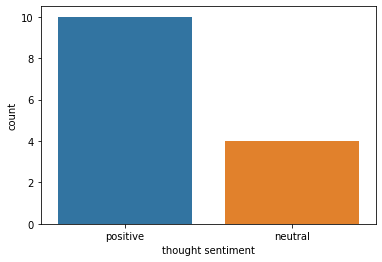

In [74]:
ax = sns.countplot(df.sentiment)
plt.xlabel('thought sentiment')
ax.set_xticklabels(labels);

# Training Model

In [75]:
# Creating the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=1500)
x = cv.fit_transform(df['thought']).toarray()
y = df['sentiment'].values

In [76]:
x.shape

(14, 202)

In [77]:
y.shape

(14,)

In [78]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.35, random_state = 0)

In [79]:
# Fitting Naive Bayes to the Training set
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()
classifier.fit(x_train, y_train)

MultinomialNB()

In [80]:
# Predicting the Test set results
y_pred = classifier.predict(x_test)

In [81]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[3, 0],
       [0, 2]], dtype=int64)

In [82]:
# Hyperparameter tuning the Naive Bayes Classifier
from sklearn.metrics import accuracy_score
best_accuracy = 0.0
alpha_val = 0.0
for i in np.arange(0.1,1.1,0.1):
  temp_classifier = MultinomialNB(alpha=i)
  temp_classifier.fit(x_train, y_train)
  temp_y_pred = temp_classifier.predict(x_test)
  score = accuracy_score(y_test, temp_y_pred)
  print("Accuracy score for alpha={} is: {}%".format(round(i,1), round(score*100,2)))
  if score>best_accuracy:
    best_accuracy = score
    alpha_val = i
print('--------------------------------------------')
print('The best accuracy is {}% with alpha value as {}'.format(round(best_accuracy*100, 2), round(alpha_val,1)))

Accuracy score for alpha=0.1 is: 100.0%
Accuracy score for alpha=0.2 is: 100.0%
Accuracy score for alpha=0.3 is: 100.0%
Accuracy score for alpha=0.4 is: 100.0%
Accuracy score for alpha=0.5 is: 100.0%
Accuracy score for alpha=0.6 is: 100.0%
Accuracy score for alpha=0.7 is: 100.0%
Accuracy score for alpha=0.8 is: 100.0%
Accuracy score for alpha=0.9 is: 100.0%
Accuracy score for alpha=1.0 is: 100.0%
--------------------------------------------
The best accuracy is 100.0% with alpha value as 0.1


# Prediction

In [83]:
import re
from nltk.stem.porter import PorterStemmer

In [84]:
def predict_sentiment(sample_thought):
  sample_thought = re.sub(pattern='[^a-zA-Z]',repl=' ', string = sample_thought)
  sample_thought = sample_thought.lower()
  sample_thought_words = sample_thought.split()
  sample_thought_words = [word for word in sample_thought_words if not word in set(stopwords.words('english'))]
  ps = PorterStemmer()
  final_thought = [ps.stem(word) for word in sample_thought_words]
  final_thought = ' '.join(final_thought)
  print(final_thought)

  temp = cv.transform([final_thought]).toarray()
  print(classifier.predict(temp))
  return classifier.predict(temp)

In [88]:
# Predicting values
sample_thought = 'Online learing is workd great for me as i like the idea of freedom of designing the schedule with my own pace'

if predict_sentiment(sample_thought) == 'pos':
  print('This is a POSITIVE thought!')
else:
  print('This is a NEUTRAL thought!')

onlin lear workd great like idea freedom design schedul pace
['neu']
This is a NEUTRAL thought!
